# QuickCart Market Basket Analysis
### Unsupervised Machine Learning Minor Project

**Objective:** Discover products that are frequently purchased together and translate association rules into practical recommendations for shelf placement, combo offers, and app cross-selling.

**Algorithms:** Apriori and FP-Growth  
**Key metrics:** Support, Confidence, and Lift  
**Dataset:** 5,000 baskets, 12 stores, and 60 products across November 2026.

> Run the notebook from top to bottom. The first code cell installs the required libraries if they are missing.

## 1. Business Problem and Questions

QuickCart wants to understand which products belong together in a shopping basket. The results can support:
- **Shelf placement:** place strongly associated products close to each other.
- **Bundle deals:** offer suitable product combinations.
- **App recommendations:** show “frequently bought together” suggestions.
- **Inventory planning:** prepare stock for products commonly bought as a pair.

This is association analysis, not customer clustering or stockout prediction.

In [2]:
import sys, subprocess, importlib.util, time, ast, re, warnings
warnings.filterwarnings("ignore")

required = {"pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib", "mlxtend": "mlxtend"}
missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from pathlib import Path

DATA_DIR = Path("data")
if not DATA_DIR.exists() and Path("../data").exists():
    DATA_DIR = Path("../data")

tx = pd.read_csv(DATA_DIR / "quickcart_basket_transactions.csv")
skus = pd.read_csv(DATA_DIR / "dim_skus.csv")
print("Transactions loaded:", tx.shape)
print("SKU catalog loaded:", skus.shape)

Transactions loaded: (26878, 6)
SKU catalog loaded: (60, 9)


## 2. Load and Understand the Data

The transaction file is in **long format**: each row represents one product in one order. Association mining needs each order represented as a basket or a one-hot encoded row.

In [3]:
display(tx.head())
display(skus.head())
print("Rows (line items):", len(tx))
print("Unique baskets:", tx["order_id"].nunique())
print("Unique SKUs:", tx["sku_id"].nunique())
print("Stores:", tx["store_id"].nunique())
print("Date range:", tx["date"].min(), "to", tx["date"].max())
print("Missing values by column:")
display(tx.isna().sum().to_frame("missing_values"))

,order_id,date,store_id,sku_id,sku_name,category
0,ORD-00001,2026-11-05,ST02,SKU025,Rusk 200g,Snacks
1,ORD-00001,2026-11-05,ST02,SKU055,White Bread 400g,Bakery
2,ORD-00001,2026-11-05,ST02,SKU009,Capsicum 500g,Fruits & Vegetables
3,ORD-00001,2026-11-05,ST02,SKU010,Toned Milk 1L,Dairy
4,ORD-00001,2026-11-05,ST02,SKU029,Energy Drink 250ml,Beverages


,sku_id,sku_name,category,unit_price_inr,shelf_life_days,is_perishable,festive_relevant,popularity_tier,supplier_id
0,SKU001,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11
1,SKU002,Tomato 1kg,Fruits & Vegetables,148.76,3,Y,N,Medium,SUP08
2,SKU003,Onion 1kg,Fruits & Vegetables,66.13,3,Y,N,High,SUP01
3,SKU004,Potato 1kg,Fruits & Vegetables,51.99,5,Y,N,High,SUP01
4,SKU005,Apple 1kg,Fruits & Vegetables,145.91,5,Y,N,Medium,SUP08


Rows (line items): 26878
Unique baskets: 5000
Unique SKUs: 60
Stores: 12
Date range: 2026-11-01 to 2026-11-30
Missing values by column:


,missing_values
order_id,0
date,0
store_id,0
sku_id,0
sku_name,0
category,0


Basket size summary


,items_per_basket
count,5000.00
mean,5.38
std,2.37
min,1.00
25%,4.00
50%,5.00
75%,7.00
max,16.00


Duplicate order-product rows: 0


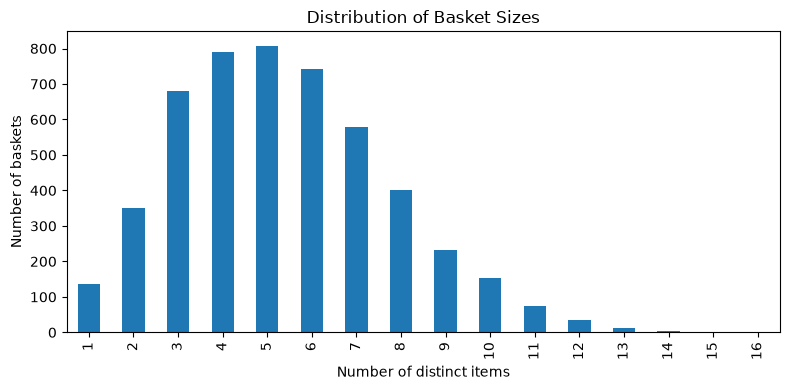

In [4]:
basket_sizes = tx.groupby("order_id")["sku_name"].nunique()
print("Basket size summary")
display(basket_sizes.describe().to_frame("items_per_basket").round(2))
print("Duplicate order-product rows:", tx.duplicated(["order_id", "sku_name"]).sum())

# Remove duplicate products within the same basket, if any.
tx = tx.drop_duplicates(["order_id", "sku_name"]).copy()
baskets = tx.groupby("order_id")["sku_name"].apply(list).tolist()

plt.figure(figsize=(8, 4))
basket_sizes.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Basket Sizes")
plt.xlabel("Number of distinct items")
plt.ylabel("Number of baskets")
plt.tight_layout()
plt.show()

## 3. Convert Baskets to One-Hot Format

Each row represents an order and each column represents a product. `True` means the product appeared in that basket.

In [5]:
encoder = TransactionEncoder()
encoded_array = encoder.fit(baskets).transform(baskets)
basket_matrix = pd.DataFrame(encoded_array, columns=encoder.columns_)
print("One-hot matrix shape:", basket_matrix.shape)
display(basket_matrix.head())

One-hot matrix shape: (5000, 60)


,Air Freshener,Apple 1kg,Banana 1kg,Banana Chips 150g,Bar Soap 125g,Basmati Rice 5kg,Besan 1kg,Brown Bread 400g,Butter 100g,Buttermilk 1L,...,Shampoo 340ml,Spinach 250g,Sugar 1kg,Toilet Cleaner 500ml,Tomato 1kg,Toned Milk 1L,Toor Dal 1kg,Toothpaste 150g,Wheat Flour 5kg,White Bread 400g
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


## 4. Explore Popular Products

Single-item support is the proportion of all baskets containing a product. This helps establish a baseline before examining combinations.

,support,support_pct
White Bread 400g,0.2546,25.46
Toned Milk 1L,0.2540,25.40
Potato Chips 90g,0.2184,21.84
Cola 750ml,0.2164,21.64
Toor Dal 1kg,0.2068,20.68
Cooking Oil 1L,0.1996,19.96
Basmati Rice 5kg,0.1982,19.82
Choco Cookies 150g,0.1776,17.76
Instant Coffee 100g,0.1770,17.70
Ghee 500ml,0.1706,17.06


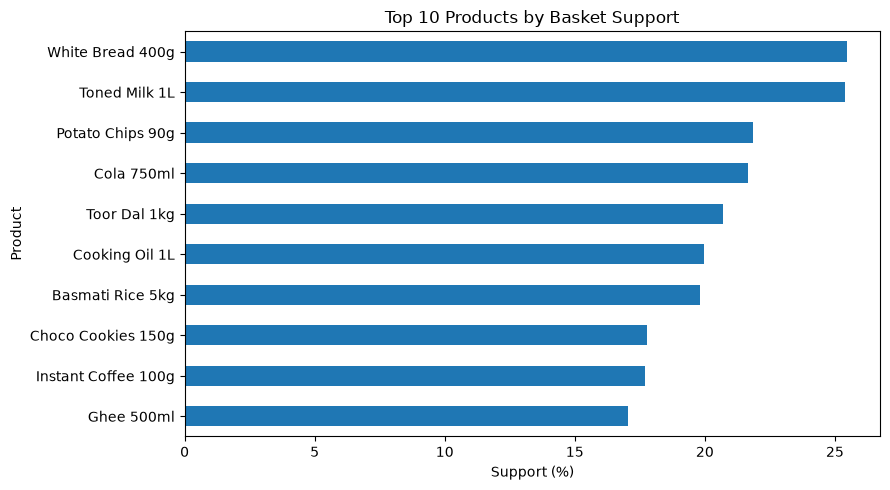

In [6]:
item_support = basket_matrix.mean().sort_values(ascending=False)
top_products = item_support.head(10)
display(top_products.rename("support").to_frame().assign(support_pct=lambda x: (x["support"]*100).round(2)))

plt.figure(figsize=(9, 5))
(top_products.sort_values() * 100).plot(kind="barh")
plt.title("Top 10 Products by Basket Support")
plt.xlabel("Support (%)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 5. Mine Frequent Itemsets with Apriori

Minimum support is set to **2%**, matching the project specification. An itemset is frequent when it occurs in at least 2% of all baskets.

In [7]:
MIN_SUPPORT = 0.02
start = time.perf_counter()
itemsets_ap = apriori(basket_matrix, min_support=MIN_SUPPORT, use_colnames=True)
apriori_seconds = time.perf_counter() - start

itemsets_ap["itemset_size"] = itemsets_ap["itemsets"].apply(len)
print(f"Apriori runtime: {apriori_seconds:.3f} seconds")
print("Frequent itemsets:", len(itemsets_ap))
display(itemsets_ap.sort_values(["itemset_size", "support"], ascending=[True, False]).head(20))
display(itemsets_ap["itemset_size"].value_counts().sort_index().rename_axis("itemset_size").to_frame("count"))

Apriori runtime: 0.061 seconds
Frequent itemsets: 256


,support,itemsets,itemset_size
59,0.2546,frozenset({White Bread 400g}),1
55,0.2540,frozenset({Toned Milk 1L}),1
44,0.2184,frozenset({Potato Chips 90g}),1
14,0.2164,frozenset({Cola 750ml}),1
56,0.2068,frozenset({Toor Dal 1kg}),1
15,0.1996,frozenset({Cooking Oil 1L}),1
5,0.1982,frozenset({Basmati Rice 5kg}),1
13,0.1776,frozenset({Choco Cookies 150g}),1
29,0.1770,frozenset({Instant Coffee 100g}),1
26,0.1706,frozenset({Ghee 500ml}),1


,count
itemset_size,
1,60
2,78
3,86
4,30
5,2


## 6. Mine Frequent Itemsets with FP-Growth

FP-Growth mines frequent itemsets using a compact tree representation and avoids the candidate-generation process used by Apriori. Both algorithms use the same minimum support to make the comparison fair.

In [8]:
start = time.perf_counter()
itemsets_fp = fpgrowth(basket_matrix, min_support=MIN_SUPPORT, use_colnames=True)
fpgrowth_seconds = time.perf_counter() - start

itemsets_fp["itemset_size"] = itemsets_fp["itemsets"].apply(len)
print(f"FP-Growth runtime: {fpgrowth_seconds:.3f} seconds")
print("Frequent itemsets:", len(itemsets_fp))
comparison = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Runtime_seconds": [apriori_seconds, fpgrowth_seconds],
    "Frequent_itemsets": [len(itemsets_ap), len(itemsets_fp)]
})
display(comparison.round(4))

FP-Growth runtime: 0.124 seconds
Frequent itemsets: 256


,Algorithm,Runtime_seconds,Frequent_itemsets
0,Apriori,0.0614,256
1,FP-Growth,0.1235,256


### Compare the results

With the same dataset and minimum support, Apriori and FP-Growth should identify the same frequent itemsets (their row order can differ). Runtime can vary by computer and library version.

In [9]:
def itemset_key(frame):
    return {frozenset(x) for x in frame["itemsets"]}

ap_keys, fp_keys = itemset_key(itemsets_ap), itemset_key(itemsets_fp)
print("Itemsets common to both:", len(ap_keys & fp_keys))
print("Only Apriori:", len(ap_keys - fp_keys))
print("Only FP-Growth:", len(fp_keys - ap_keys))
print("Same frequent itemsets:", ap_keys == fp_keys)

Itemsets common to both: 256
Only Apriori: 0
Only FP-Growth: 0
Same frequent itemsets: True


## 7. Generate Association Rules

- **Support:** fraction of all baskets containing both sides of the rule.
- **Confidence:** probability of buying the consequent when the antecedent is present.
- **Lift:** confidence divided by the consequent's overall support. Lift above 1 indicates a positive association.

Lift alone can be misleading: a very high-lift rule with low support may be based on relatively few baskets. Consider all three metrics together.

In [10]:
rules = association_rules(itemsets_ap.drop(columns=["itemset_size"]), metric="lift", min_threshold=1.0)
rules["antecedent_size"] = rules["antecedents"].apply(len)
rules["consequent_size"] = rules["consequents"].apply(len)

def items_text(items):
    return ", ".join(sorted(items))

rules["antecedents_text"] = rules["antecedents"].apply(items_text)
rules["consequents_text"] = rules["consequents"].apply(items_text)
rules = rules.sort_values(["lift", "confidence", "support"], ascending=False).reset_index(drop=True)

display(rules[["antecedents_text", "consequents_text", "support", "confidence", "lift"]].head(15).round(4))
print("Rules generated:", len(rules))

,antecedents_text,consequents_text,support,confidence,lift
0,"Choco Cookies 150g, Face Wash 100ml","Hand Sanitizer 200ml, Instant Coffee 100g",0.0206,0.7518,26.8509
1,"Hand Sanitizer 200ml, Instant Coffee 100g","Choco Cookies 150g, Face Wash 100ml",0.0206,0.7357,26.8509
2,"Choco Cookies 150g, Hand Sanitizer 200ml","Face Wash 100ml, Instant Coffee 100g",0.0206,0.7464,26.8481
3,"Face Wash 100ml, Instant Coffee 100g","Choco Cookies 150g, Hand Sanitizer 200ml",0.0206,0.7410,26.8481
4,"Ghee 500ml, Instant Coffee 100g","Choco Cookies 150g, Poha 500g",0.0234,0.7852,26.0012
5,"Choco Cookies 150g, Poha 500g","Ghee 500ml, Instant Coffee 100g",0.0234,0.7748,26.0012
6,"Instant Coffee 100g, Poha 500g","Choco Cookies 150g, Ghee 500ml",0.0234,0.7800,25.3247
7,"Choco Cookies 150g, Ghee 500ml","Instant Coffee 100g, Poha 500g",0.0234,0.7597,25.3247
8,"Ghee 500ml, Toned Milk 1L","Poha 500g, White Bread 400g",0.0292,0.8022,21.7989
9,"Poha 500g, White Bread 400g","Ghee 500ml, Toned Milk 1L",0.0292,0.7935,21.7989


Rules generated: 980


## 8. Filter for Actionable Rules

For a practical shortlist, use support above 5%, lift above 2, and confidence above 60%. These are business filters, not universal statistical cutoffs. Change them if your project brief or instructor specifies different thresholds.

Actionable rules: 29


,antecedents_text,consequents_text,support,confidence,lift
616,Toned Milk 1L,White Bread 400g,0.2384,0.9386,3.6865
617,White Bread 400g,Toned Milk 1L,0.2384,0.9364,3.6865
352,Cola 750ml,Potato Chips 90g,0.1974,0.9122,4.1767
353,Potato Chips 90g,Cola 750ml,0.1974,0.9038,4.1767
539,Cooking Oil 1L,Toor Dal 1kg,0.1544,0.7735,3.7406
538,Toor Dal 1kg,Cooking Oil 1L,0.1544,0.7466,3.7406
534,Basmati Rice 5kg,Toor Dal 1kg,0.1534,0.7740,3.7426
535,Toor Dal 1kg,Basmati Rice 5kg,0.1534,0.7418,3.7426
292,Instant Coffee 100g,Choco Cookies 150g,0.1520,0.8588,4.8353
293,Choco Cookies 150g,Instant Coffee 100g,0.1520,0.8559,4.8353


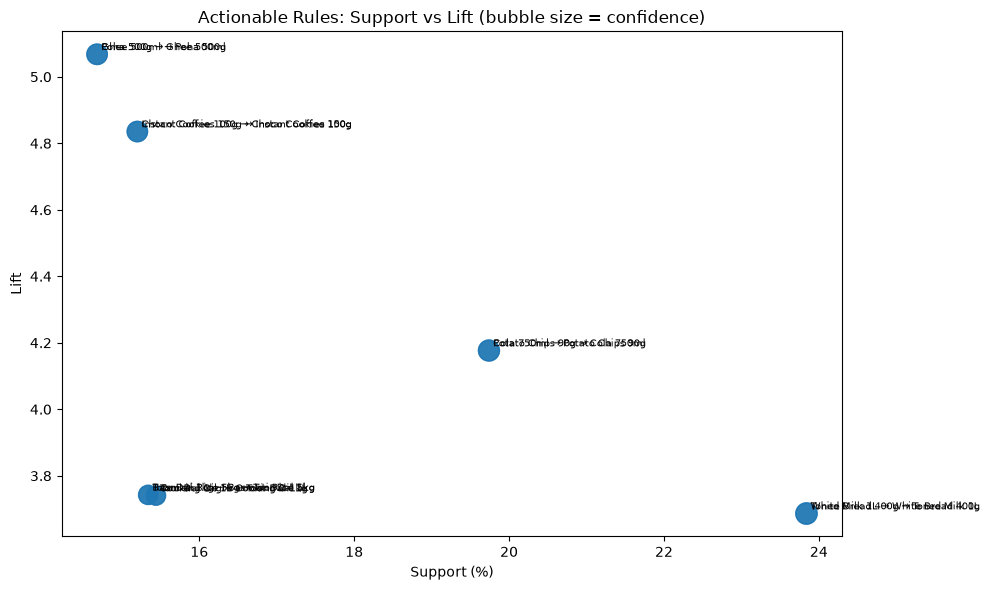

In [11]:
actionable = rules[
    (rules["support"] > 0.05) &
    (rules["lift"] > 2) &
    (rules["confidence"] >= 0.60)
].copy()

actionable = actionable.sort_values(["support", "confidence", "lift"], ascending=False)
print("Actionable rules:", len(actionable))
display(actionable[["antecedents_text", "consequents_text", "support", "confidence", "lift"]].head(25).round(4))

if len(actionable):
    plot_rules = actionable.head(12).copy()
    plot_rules["rule"] = plot_rules["antecedents_text"] + " → " + plot_rules["consequents_text"]
    plt.figure(figsize=(10, 6))
    plt.scatter(plot_rules["support"] * 100, plot_rules["lift"], s=plot_rules["confidence"] * 250, alpha=0.75)
    for _, row in plot_rules.iterrows():
        plt.annotate(row["rule"][:42], (row["support"]*100, row["lift"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    plt.title("Actionable Rules: Support vs Lift (bubble size = confidence)")
    plt.xlabel("Support (%)")
    plt.ylabel("Lift")
    plt.tight_layout()
    plt.show()

## 9. Validate the Six Expected Business Patterns

The project specification lists six planted product associations. This cell checks their direction in the mined rules. Small differences may arise from using different versions of the source data or parameter settings.

In [12]:
expected = [
    ("Toned Milk 1L", "White Bread 400g", "Breakfast Combo"),
    ("Basmati Rice 1kg", "Toor Dal 1kg", "Thali Staples"),
    ("Potato Chips 90g", "Cola 750ml", "Snack-Drink Combo"),
    ("Ghee 500ml", "Poha 500g", "Ghar Breakfast"),
    ("Instant Coffee 100g", "Choco Cookies 150g", "Tea-Time"),
    ("Hand Sanitizer 200ml", "Face Wash 100ml", "Personal Care Restock"),
]

validation_rows = []
for antecedent, consequent, label in expected:
    found = rules[
        rules["antecedents"].apply(lambda s: s == frozenset([antecedent])) &
        rules["consequents"].apply(lambda s: s == frozenset([consequent]))
    ]
    if found.empty:
        validation_rows.append({"Pattern": label, "Rule": f"{antecedent} → {consequent}",
                                "Support": np.nan, "Confidence": np.nan, "Lift": np.nan, "Found": "No"})
    else:
        row = found.iloc[0]
        validation_rows.append({"Pattern": label, "Rule": f"{antecedent} → {consequent}",
                                "Support": row["support"], "Confidence": row["confidence"],
                                "Lift": row["lift"], "Found": "Yes"})
validation = pd.DataFrame(validation_rows)
display(validation.style.format({"Support":"{:.2%}", "Confidence":"{:.2%}", "Lift":"{:.2f}"}))

,Pattern,Rule,Support,Confidence,Lift,Found
0,Breakfast Combo,Toned Milk 1L → White Bread 400g,23.84%,93.86%,3.69,Yes
1,Thali Staples,Basmati Rice 1kg → Toor Dal 1kg,nan%,nan%,nan,No
2,Snack-Drink Combo,Potato Chips 90g → Cola 750ml,19.74%,90.38%,4.18,Yes
3,Ghar Breakfast,Ghee 500ml → Poha 500g,14.68%,86.05%,5.07,Yes
4,Tea-Time,Instant Coffee 100g → Choco Cookies 150g,15.20%,85.88%,4.84,Yes
5,Personal Care Restock,Hand Sanitizer 200ml → Face Wash 100ml,13.18%,79.30%,5.05,Yes


## 10. Business Recommendations

Use the strongest **reliable** rules—not just the largest lift—to make decisions. The six expected pairs provide intuitive examples of how the findings can be applied.

In [13]:
recommendations = pd.DataFrame([
    ["Toned Milk 1L + White Bread 400g", "Breakfast combo; place milk and bread in adjacent recommendation slots.", "High confidence and broad everyday use."],
    ["Basmati Rice 1kg + Toor Dal 1kg", "Create a pantry / thali bundle and cross-sell dal when rice is added.", "Complementary meal staples."],
    ["Potato Chips 90g + Cola 750ml", "Offer a snack-and-drink combo and a checkout prompt.", "Convenient occasion-based pairing."],
    ["Ghee 500ml + Poha 500g", "Promote a breakfast bundle and place both in a breakfast collection.", "Useful pairing for a common meal."],
    ["Instant Coffee 100g + Choco Cookies 150g", "Create a tea-time / coffee-break recommendation.", "Good fit for cross-sell prompts."],
    ["Hand Sanitizer 200ml + Face Wash 100ml", "Show a personal-care replenishment recommendation.", "Related personal-care purchase intent."]
], columns=["Association", "Suggested action", "Reason"])
display(recommendations)

,Association,Suggested action,Reason
0,Toned Milk 1L + White Bread 400g,Breakfast combo; place milk and bread in adjac...,High confidence and broad everyday use.
1,Basmati Rice 1kg + Toor Dal 1kg,Create a pantry / thali bundle and cross-sell ...,Complementary meal staples.
2,Potato Chips 90g + Cola 750ml,Offer a snack-and-drink combo and a checkout p...,Convenient occasion-based pairing.
3,Ghee 500ml + Poha 500g,Promote a breakfast bundle and place both in a...,Useful pairing for a common meal.
4,Instant Coffee 100g + Choco Cookies 150g,Create a tea-time / coffee-break recommendation.,Good fit for cross-sell prompts.
5,Hand Sanitizer 200ml + Face Wash 100ml,Show a personal-care replenishment recommendat...,Related personal-care purchase intent.


## 11. Export Results

The notebook exports itemsets, all generated rules, and the actionable shortlist to the `outputs` folder. These files can be attached to a report or reviewed in Excel.

In [14]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def save_itemsets(frame, path):
    out = frame.copy()
    out["itemsets"] = out["itemsets"].apply(items_text)
    out.to_csv(path, index=False)

save_itemsets(itemsets_ap, OUTPUT_DIR / "frequent_itemsets_apriori.csv")
save_itemsets(itemsets_fp, OUTPUT_DIR / "frequent_itemsets_fpgrowth.csv")

rule_export_cols = ["antecedents_text", "consequents_text", "antecedent support",
                    "consequent support", "support", "confidence", "lift",
                    "leverage", "conviction"]
rules[rule_export_cols].to_csv(OUTPUT_DIR / "association_rules.csv", index=False)
actionable[rule_export_cols].to_csv(OUTPUT_DIR / "actionable_rules.csv", index=False)
validation.to_csv(OUTPUT_DIR / "expected_pattern_validation.csv", index=False)
recommendations.to_csv(OUTPUT_DIR / "business_recommendations.csv", index=False)

print("Saved output files:")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", file)

Saved output files:
- outputs\actionable_rules.csv
- outputs\association_rules.csv
- outputs\business_recommendations.csv
- outputs\expected_pattern_validation.csv
- outputs\frequent_itemsets_apriori.csv
- outputs\frequent_itemsets_fpgrowth.csv


## 12. Conclusion

Market Basket Analysis helps QuickCart identify meaningful co-purchase relationships from transaction logs. Apriori and FP-Growth produce frequent itemsets, while association rules quantify relationships through support, confidence, and lift. The strongest practical use cases are relevant bundles, better product adjacency, and contextual cross-selling.

### Limitations
- Association does not prove that one product causes the purchase of another.
- Rules can change by store, season, promotions, and customer mix.
- Low-support rules may be unstable even when lift is high.
- Validate recommendations with controlled experiments before rolling them out widely.